# Notebook 1 — The two-center two-electron bond (H₂): covalent/ionic weights, the singlet–triplet gap, and charge-shift bonding

**Goal.** Build the textbook 2c2e VB object, the H₂ bond, end-to-end with the
`symvb` symbolic toolkit: from a list of Slater determinants to a closed-form
ground-state energy and the covalent/ionic decomposition of the wave
function. By the end you will have *derived*, not quoted, the closed form

$$
E_{\text{gs}}(U, h, s),\qquad
E_{\text{gs}}(U, t)\big|_{s=0} = \tfrac{U}{2} - \sqrt{\bigl(\tfrac{U}{2}\bigr)^{2} + 4t^{2}},
$$

seen it pass continuously between the **molecular-orbital** and
**Heitler–London** pictures as $U/t$ varies, and worked out three things that
keeping the AO overlap $s$ symbolic makes visible:

- the covalent and ionic Chirgwin–Coulson **weights** are an exact $50/50$
  at $U = 0$ for *every* $s$;
- the **singlet–triplet gap** splits into a direct overlap term and an
  overlap-suppressed superexchange term (manuscript Eq. 7);
- the bond splits into the covalent structure's binding and the
  covalent–ionic resonance, the distinction that defines a **charge-shift
  bond**, with the resonance taking over as the overlap shrinks.

This is the companion notebook to the manuscript's two-center two-electron
section (Eqs 5–7 and Figure 1), and the building block for Notebooks 2–4.

**Prerequisites.** Linear algebra; familiarity with Slater determinants
at the level of one quantum-chemistry course. No prior exposure to
`symvb` or `sympy` assumed.

**Runtime.** All cells run in seconds.

## 1. Setup

The only hard dependency is `sympy`; we use `numpy`/`matplotlib` for the
final plot. The `init_printing()` call turns on LaTeX rendering for
sympy outputs in Jupyter.

In [1]:
import sympy as sp
from sympy import init_printing
init_printing()

# Render 'label = expr' as LaTeX in Jupyter; falls back to print without IPython.
try:
    from IPython.display import display, Math
    def show(label, expr):
        display(Math(label + ' = ' + sp.latex(expr)))
except ImportError:
    def show(label, expr):
        print(label, '=', expr)

from symvb import Molecule
from symvb.fixed_psi import generate_dets

## 2. One-electron warm-up: the bonding and antibonding levels

Before adding the second electron, look at the one-electron problem: a
single electron shared between the two atomic orbitals $\{a, b\}$, that is
the H₂⁺ cation. This is the simplest non-orthogonal VB object, and it fixes
the one-electron coupling $h = \langle a|\hat h|b\rangle$ and overlap
$s = \langle a|b\rangle$ that carry into everything below.

`generate_dets(1, 0, 2)` builds the one-$\alpha$-electron, two-orbital
basis; the `System` facade's `hamiltonian()` returns the $2\times2$ $H$ and
$S$; the two roots of $\det(H - E\,S) = 0$ are the Hückel levels

$$
E_{\text{bond}} = \frac{h}{1 + s}, \qquad
E_{\text{anti}} = -\,\frac{h}{1 - s},
$$

the manuscript's Eq. 4. With the Hückel sign convention $h < 0$,
$E_{\text{bond}}$ is the lower, bonding level; both reduce to $\pm h$ at
orthogonal AOs ($s = 0$).

In [2]:
from symvb import Molecule, System
from symvb.fixed_psi import generate_dets

h, s = sp.symbols('h s')
m1 = Molecule(zero_ii=True, interacting_orbs=['ab'],
              subst={'h': ('H_ab',), 's': ('S_ab',)})
bond1e = System(m1, generate_dets(1, 0, 2))            # one electron in two orbitals (H2+)
H1, S1 = bond1e.hamiltonian()

E = sp.symbols('E')
levels = [sp.simplify(L) for L in sp.solve((H1 - E*S1).det(), E)]
show(r'\text{one-electron Huckel levels (Eq.~4)}', sp.Matrix(levels))   # h/(1+s), -h/(1-s)
assert {sp.simplify(L) for L in levels} == {sp.simplify(h/(1+s)), sp.simplify(-h/(1-s))}

<IPython.core.display.Math object>

## 3. The four-determinant basis

Two electrons in two spatial orbitals $\{a, b\}$ live in a four-
dimensional Hilbert space once we restrict to $S_{z} = 0$ (one $\alpha$,
one $\beta$). `symvb` writes spin-orbitals with **case**: lowercase = $\alpha$,
uppercase = $\beta$. The four determinants in the $S_{z}=0$ sector are

| string | spin-orbitals | physical interpretation |
|---|---|---|
| `aA` | $a_{\alpha}, a_{\beta}$ | both electrons on atom $a$ — *ionic* |
| `aB` | $a_{\alpha}, b_{\beta}$ | one each, $\alpha$ on $a$ — covalent piece |
| `bA` | $b_{\alpha}, a_{\beta}$ | one each, $\alpha$ on $b$ — covalent piece |
| `bB` | $b_{\alpha}, b_{\beta}$ | both on atom $b$ — *ionic* |

`generate_dets(Nela, Nelb, Norb)` returns this basis, wrapped in
`FixedPsi` objects (a `FixedPsi` is a linear combination of dets; here
each contains a single det).

In [3]:
# generate_dets(Nela, Nelb, Norb) — alpha count, beta count, orbital count
P = generate_dets(1, 1, 2)
[p.dets[0].det_string for p in P]

['aA', 'aB', 'bA', 'bB']

## 4. Building H and S symbolically

`Molecule` is a parameter container that tells `symvb` how to translate
spin-orbital indices into physical integrals when computing matrix
elements between determinants. Three key parameters:

- **`subst={'h': ('H_ab',), 's': ('S_ab',)}`** — replace the internal
  one-electron coupling `H_ab` and overlap `S_ab` with the symbols `h`
  and `s`. (Site energies $H_{aa}, H_{bb}$ are zeroed below.)
- **`zero_ii=True`** — set on-site one-electron integrals to zero. This
  removes a constant shift and lets us focus on the bonding physics.
- **`subst_2e={'U': ('1111',)}` with `max_2e_centers=1`** — keep only
  the on-site Coulomb $\langle aa | aa \rangle = U$ (and $\langle bb |
  bb \rangle = U$); drop all two-center two-electron integrals. This is
  precisely the Hubbard model.
- **`interacting_orbs=['ab']`** — only $a$ and $b$ are connected; in a
  larger problem you would list all bonded pairs.

Matrix elements between non-orthogonal Slater determinants come from
**Löwdin's cofactor theorem**: for two normalised dets $|\Phi\rangle,
|\Phi'\rangle$ with spin-orbital overlap matrix $D$,
$\langle \Phi | \hat{F} | \Phi'\rangle = \sum_{ij} F_{ij}\,
\text{cof}(D)_{ij}$ (one-electron operators), with a similar formula
for two-electron operators. `symvb.build_matrix` and `o2_matrix` perform
these contractions symbolically.

In [4]:
m = Molecule(
    zero_ii=True,
    interacting_orbs=['ab'],
    subst={'h': ('H_ab',), 's': ('S_ab',)},
    subst_2e={'U': ('1111',)},
    max_2e_centers=1,
)

H_1e = sp.Matrix(m.build_matrix(P, op='H'))
S    = sp.Matrix(m.build_matrix(P, op='S'))
H_2e = sp.Matrix(m.o2_matrix(P))
H    = H_1e + H_2e

In [5]:
sp.simplify(S)

⎡             2⎤
⎢1   s   s   s ⎥
⎢              ⎥
⎢         2    ⎥
⎢s   1   s   s ⎥
⎢              ⎥
⎢     2        ⎥
⎢s   s   1   s ⎥
⎢              ⎥
⎢ 2            ⎥
⎣s   s   s   1 ⎦

In [6]:
sp.simplify(H)

⎡  U      h      h    2⋅h⋅s⎤
⎢                          ⎥
⎢  h      0    2⋅h⋅s    h  ⎥
⎢                          ⎥
⎢  h    2⋅h⋅s    0      h  ⎥
⎢                          ⎥
⎣2⋅h⋅s    h      h      U  ⎦

## 5. Reading the matrices

Each determinant is normalised individually, so every diagonal entry of
$S$ is $1$. The off-diagonals come from the cofactor formula. Recall
the basis order is `[aA, aB, bA, bB]`.

- **One spin-orbital differs** ($s$ entries): `S[aA, aB] = s` because
  the only difference between $|aA\rangle$ and $|aB\rangle$ is the
  $\beta$-electron orbital ($a \to b$); the cofactor reduces to a
  single one-orbital overlap $\langle a | b \rangle = s$. Same for
  `S[aA, bA]`, `S[aB, bB]`, `S[bA, bB]`.
- **Two spin-orbitals differ** ($s^{2}$ entries): `S[aA, bB] = s²` —
  both $\alpha$ and $\beta$ electrons changed orbital; the cofactor is
  the product of two overlaps. Same for `S[aB, bA]`.

For the Hamiltonian:

- **`H[aA, aA] = U`** — both electrons on atom $a$; pay one on-site
  Coulomb. The one-electron piece is zero by `zero_ii=True`.
- **`H[aB, aB] = H[bA, bA] = 0`** — covalent dets: zero one-electron
  on-site and zero two-electron because the electrons are on
  *different* atoms (we kept only the on-site $U$).
- **`H[aA, aB] = h`** — one-substitution coupling: this is the
  resonance integral. Survives even at $s = 0$.
- **`H[aA, bB] = 2hs`** — two-substitution coupling. Vanishes at $s =
  0$ — this is the Brillouin-style suppression that disappears once
  AOs are non-orthogonal.

> **Exercise 1.** Count how many spin-orbitals differ between each
> pair of determinants. Use the Slater–Condon rules for orthogonal
> orbitals to predict which $H$ entries should vanish at $s = 0$.
> Confirm with the next cell.

In [7]:
sp.simplify(H.subs(sp.Symbol('s'), 0))

⎡U  h  h  0⎤
⎢          ⎥
⎢h  0  0  h⎥
⎢          ⎥
⎢h  0  0  h⎥
⎢          ⎥
⎣0  h  h  U⎦

## 6. Symmetry-adapted basis: covalent and ionic singlets

The Hamiltonian commutes with the spatial swap $a \leftrightarrow b$
(the $\sigma_{v}$ of $D_{\infty h}$) and with $\hat{S}^{2}$. The
symmetric singlet block is two-dimensional, spanned by

$$
|\text{cov}\rangle = \tfrac{1}{N_{\text{cov}}} \bigl(|aB\rangle +
|bA\rangle\bigr), \qquad
|\text{ion}\rangle = \tfrac{1}{N_{\text{ion}}} \bigl(|aA\rangle +
|bB\rangle\bigr),
$$

with $N_{\text{cov}} = N_{\text{ion}} = \sqrt{2(1+s^{2})}$ in the
non-orthogonal basis. **`|cov⟩` is the Heitler–London singlet** (one
electron per atom, spin-paired); **`|ion⟩` is the symmetric
combination of doubly-occupied atomic configurations**. The
antisymmetric covalent combination $(|aB\rangle - |bA\rangle)$ is the
$M_{S}=0$ component of the triplet and is decoupled from the singlet
sector.

In [8]:
h, s, U = sp.symbols('h s U')

idx = {p.dets[0].det_string: i for i, p in enumerate(P)}
N = sp.sqrt(2 * (1 + s**2))

cov = sp.zeros(4, 1); cov[idx['aB']] = 1; cov[idx['bA']] = 1; cov /= N
ion = sp.zeros(4, 1); ion[idx['aA']] = 1; ion[idx['bB']] = 1; ion /= N

T = sp.Matrix.hstack(cov, ion).T          # rows = {cov, ion}
H_A1 = sp.simplify(T * H * T.T)
S_A1 = sp.simplify(T * S * T.T)
H_A1, S_A1

⎛⎡2⋅h⋅s     2⋅h    ⎤  ⎡         2⋅s  ⎤⎞
⎜⎢──────   ──────  ⎥  ⎢  1     ──────⎥⎟
⎜⎢ 2        2      ⎥  ⎢         2    ⎥⎟
⎜⎢s  + 1   s  + 1  ⎥  ⎢        s  + 1⎥⎟
⎜⎢                 ⎥, ⎢              ⎥⎟
⎜⎢ 2⋅h    U + 2⋅h⋅s⎥  ⎢ 2⋅s          ⎥⎟
⎜⎢──────  ─────────⎥  ⎢──────    1   ⎥⎟
⎜⎢ 2        2      ⎥  ⎢ 2            ⎥⎟
⎝⎣s  + 1   s  + 1  ⎦  ⎣s  + 1        ⎦⎠

## 7. Closed-form ground-state energy

We have a $2\times 2$ generalised eigenvalue problem
$H_{A_{1}} c = E\, S_{A_{1}} c$. Sympy can solve it in one line.

To pick the **ground state** out of the two roots, we use a physical
limit: at $U=0$ and $h=-1$ the ground-state energy of the H₂ dimer is
$-2|h|/(1+s) = -2$ (per the bonding MO doubly occupied). We filter for
that root.

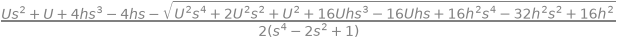

In [9]:
E = sp.Symbol('E')
roots = sp.solve((H_A1 - E * S_A1).det(), E)
E_gs = [r for r in roots
        if sp.simplify(r.subs({U: 0, s: 0, h: -1}) - (-2)) == 0][0]
E_gs = sp.simplify(E_gs)
E_gs

That is the **complete H₂ Hubbard ground state in the orthogonal-AO
limit and its non-orthogonal extension** — six lines of code from
"give me the four determinants" to a closed-form expression. Two
sanity checks:

In [10]:
sp.simplify(E_gs.subs(s, 0))     # textbook orthogonal-AO result

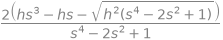

In [11]:
sp.simplify(E_gs.subs(U, 0))     # bonding MO at U=0

## 8. Three limits and the covalent/ionic crossover

**At $U=0$:** the energy reduces to $2h/(1+s)$ — twice the energy of the
bonding MO $\sigma_{g} = (a+b)/\sqrt{2(1+s)}$ doubly occupied. This is
restricted Hartree–Fock for H₂, a single closed-shell determinant.

**At $U \to \infty$:** the ionic configurations become energetically
prohibitive. Expanding for large $U$,
$E_{\text{gs}} \to -4t^{2}/U + O(U^{-2})$ (with $t = |h|$, $s = 0$) — the
Heitler–London limit, with effective antiferromagnetic exchange
$J_{\text{AFM}} = 4t^{2}/U$ between the two electrons.

**In between:** the wave function smoothly interpolates. Compute the
**Chirgwin–Coulson weights** $w_{\text{cov}}, w_{\text{ion}}$, defined
through the metric overlap so that they sum to one even at $s \ne 0$.

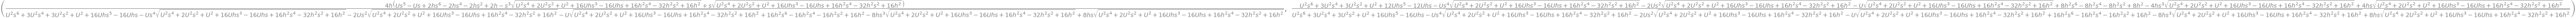

In [12]:
# Solve (H_A1 - E_gs S_A1) c = 0 for c_ion / c_cov
r = sp.Symbol('r')
M = H_A1 - E_gs * S_A1
r_sol = sp.solve(M[0, 0] + M[0, 1] * r, r)[0]
c = sp.Matrix([1, r_sol])

norm2 = sp.simplify((c.T * S_A1 * c)[0, 0])
Sc = S_A1 * c
w_cov = sp.simplify(c[0] * Sc[0] / norm2)
w_ion = sp.simplify(c[1] * Sc[1] / norm2)
w_cov, w_ion

In [13]:
# Numerical scan at s = 0
print(f"{'U':>5}  {'E_gs':>10}  {'w_cov':>8}  {'w_ion':>8}  interpretation")
for Uval in [0.0, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 100.0]:
    subs = {U: Uval, h: -1, s: 0}
    E_num = float(E_gs.subs(subs))
    wc    = float(w_cov.subs(subs))
    wi    = float(w_ion.subs(subs))
    tag = ("HF-like (50/50)"        if abs(wc - 0.5) < 0.05 else
           "predominantly covalent" if wc > 0.8 else
           "mixed covalent/ionic")
    print(f"  {Uval:4.1f}  {E_num:+10.6f}  {wc:7.4f}  {wi:7.4f}  {tag}")

    U        E_gs     w_cov     w_ion  interpretation
   0.0   -2.000000   0.5000   0.5000  HF-like (50/50)
   0.5   -1.765564   0.5620   0.4380  mixed covalent/ionic
   1.0   -1.561553   0.6213   0.3787  mixed covalent/ionic
   2.0   -1.236068   0.7236   0.2764  mixed covalent/ionic
   4.0   -0.828427   0.8536   0.1464  predominantly covalent
   8.0   -0.472136   0.9472   0.0528  predominantly covalent
  16.0   -0.246211   0.9851   0.0149  predominantly covalent
  100.0   -0.039984   0.9996   0.0004  predominantly covalent


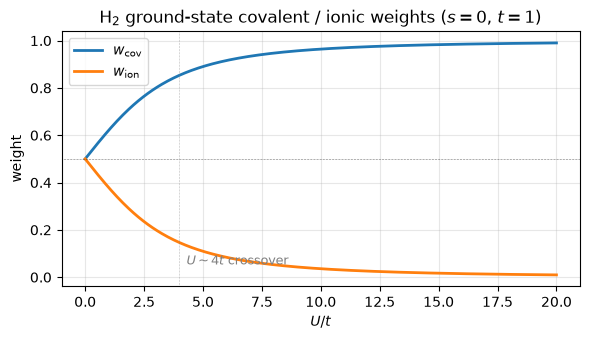

In [14]:
import numpy as np
import matplotlib.pyplot as plt

U_vals = np.linspace(0, 20, 400)
wc_vals = [float(w_cov.subs({U: Uv, h: -1, s: 0})) for Uv in U_vals]
wi_vals = [1 - x for x in wc_vals]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(U_vals, wc_vals, label=r'$w_{\rm cov}$', lw=2)
ax.plot(U_vals, wi_vals, label=r'$w_{\rm ion}$', lw=2)
ax.axhline(0.5, color='k', lw=0.4, ls=':')
ax.axvline(4, color='gray', lw=0.4, ls=':')
ax.text(4.3, 0.05, r'$U \sim 4t$ crossover', fontsize=9, color='gray')
ax.set_xlabel(r'$U / t$'); ax.set_ylabel('weight')
ax.set_title('H$_2$ ground-state covalent / ionic weights ($s = 0$, $t = 1$)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. The MO ↔ VB equivalence

Two pictures of the same ground state:

- **MO picture** (Mulliken, Hund). Build symmetric/antisymmetric MOs
  $\sigma_{g} = (a+b)/\sqrt{2}$ and $\sigma_{u} = (a-b)/\sqrt{2}$,
  doubly occupy $\sigma_{g}$, then add a CI correction
  $|\sigma_{u}^{2}\rangle$ to recover the ionic suppression at large
  $U$. This is two-configuration SCF (TCSCF / 2×2 CASSCF).
- **VB picture** (Heitler–London, Pauling). Start from $|\text{cov}\rangle$
  and dress with a controlled admixture of $|\text{ion}\rangle$. The
  ionic admixture goes to zero as $U/t \to \infty$.

The change of basis $\{|aA\rangle, |aB\rangle, |bA\rangle, |bB\rangle\}
\Leftrightarrow \{|\sigma_{g}^{2}\rangle, |\sigma_{g}\sigma_{u}\rangle_{S},
|\sigma_{g}\sigma_{u}\rangle_{T}, |\sigma_{u}^{2}\rangle\}$ is unitary
in the orthogonal-AO limit; both pictures yield the *same* eigenvalue
formula above. The VB basis just makes the correlation cost
$U$-dependence transparent: covalent costs zero on-site repulsion,
ionic costs $U$. The MO picture hides this in the $\sigma_{u}^{2}$
admixture coefficient.

## 10. Turning on AO overlap, $s \ne 0$

Real atomic orbitals on neighbouring atoms are not orthogonal:
typically $s = \langle a | b \rangle \approx 0.6$–$0.8$ for H₂ at
equilibrium. The closed-form $E_{\text{gs}}(U, h, s)$ from §7 already
included $s$. Two surprises emerge.

**Surprise 1.** At $U = 0$, $w_{\text{cov}} = 1/2$ for *all* $s$. The
restricted-HF "50/50 covalent–ionic" balance is invariant to overlap.

In [15]:
sp.simplify(w_cov.subs(U, 0))

**Surprise 2.** Overlap reshapes the singlet–triplet gap. The $M_S = 0$
triplet is the *antisymmetric* covalent combination
$|{\rm trip}\rangle \propto |aB\rangle - |bA\rangle$, decoupled from the
singlet sector, so its energy is a single Rayleigh quotient. We build it,
read off $E_{\rm trip}$, and subtract the singlet ground state.

In [16]:
t = sp.Symbol('t', positive=True)            # write h = -t, t > 0
trip = sp.zeros(4, 1); trip[idx['aB']] = 1; trip[idx['bA']] = -1
E_trip = sp.simplify((trip.T * H * trip)[0] / (trip.T * S * trip)[0])
show(r'E_{\rm trip}', E_trip)                 # = -2 h s / (1 - s^2)  = 2 t s / (1 - s^2)

<IPython.core.display.Math object>

Expanding the gap $E_{\rm trip} - E_{\rm sing}$ for large $U$ (small $1/U$)
gives the manuscript's Eq. 7, a sum of two terms:

$$
E_{\rm trip} - E_{\rm sing}
 = \underbrace{\frac{4 t s}{1 - s^4}}_{\text{direct overlap}}
 + \underbrace{\frac{4 t^2 (1 - s^2)^2}{U\,(1 + s^2)^3}}_{\text{superexchange}}
 + \mathcal{O}(1/U^2).
$$

In [17]:
gap = sp.simplify((E_trip - E_gs).subs(h, -t))      # E_trip - E_sing, with h = -t
direct = 4*t*s / (1 - s**4)                          # Eq. 7 direct overlap term
superx = 4*t**2 * (1 - s**2)**2 / (1 + s**2)**3      # Eq. 7 superexchange coefficient (x 1/U)
show(r'\text{direct overlap term}', direct)
show(r'U \times \text{superexchange term}', superx)
# verify  gap = direct + superx/U + O(1/U^2)  by the large-U limit at sample overlaps
# (a concrete rational s avoids the sqrt-branch ambiguity of a fully symbolic limit)
for sv in [sp.Rational(1, 4), sp.Rational(1, 3), sp.Rational(1, 2)]:
    g = gap.subs(s, sv)
    assert sp.simplify(sp.limit(g, U, sp.oo) - direct.subs(s, sv)) == 0
    assert sp.simplify(sp.limit((g - direct.subs(s, sv)) * U, U, sp.oo) - superx.subs(s, sv)) == 0
print("\ngap -> direct + superx/U verified at s = 1/4, 1/3, 1/2  -> OK")

<IPython.core.display.Math object>

<IPython.core.display.Math object>


gap -> direct + superx/U verified at s = 1/4, 1/3, 1/2  -> OK


Two readings:

- The **superexchange** term is the non-orthogonal generalization of the
  textbook $4t^2/U$: the same virtual hop through the doubly-occupied ionic
  configuration that sets the $-4t^2/U$ binding above. Its overlap factor
  $(1 - s^2)^2/(1 + s^2)^3$ *suppresses* it, to $0.733$ of the $s = 0$ value
  at $s = 0.25$.
- The **direct** term $4ts/(1 - s^4)$, absent at orthogonal AOs, is a
  $U$-independent singlet preference created by overlap itself; at strong
  coupling it dominates the gap.

In [20]:
factor = sp.simplify(superx / (4*t**2))      # the (1-s^2)^2/(1+s^2)^3 overlap factor
print(f"superexchange overlap factor at s = 0.25:  "
      f"{float(factor.subs(s, sp.Rational(1,4))):.3f}   (manuscript 0.733)")
full = float(gap.subs({U: 100, t: 1, s: sp.Rational(1,4)}))
sx   = float((superx/U).subs({U: 100, t: 1, s: sp.Rational(1,4)}))
print(f"at U = 100 t, s = 0.25:  full gap = {full:.3f} t,  "
      f"superexchange channel only = {sx:.3f} t")

superexchange overlap factor at s = 0.25:  0.733   (manuscript 0.733)
at U = 100 t, s = 0.25:  full gap = 1.033 t,  superexchange channel only = 0.029 t


Keeping overlap $s$ symbolic surfaces non-orthogonality corrections that
parametrized model Hamiltonians (Hubbard, Heisenberg, t-J) drop by
construction. The same trick exposes one more feature of the bond.

## 11. The charge-shift split

The same $2\times 2$ separates the bond into the binding the **covalent
structure** supplies and the **covalent–ionic resonance**, the distinction
that defines a *charge-shift* bond. The covalent structure's own energy is
its diagonal $H_{A_1}[0,0] = 2hs/(1 + s^2)$: it binds **only through the
overlap** $s$. The covalent–ionic coupling is the off-diagonal $2h/(1 + s^2)$,
largest at $s = 0$. So as the overlap shrinks (the more compact atoms of an
electronegative element such as fluorine), the covalent structure weakens
while the resonance strengthens.

In [21]:
E_cov_struct = sp.simplify(H_A1[0, 0] / S_A1[0, 0])     # covalent structure alone = 2 h s/(1+s^2)
show(r'E_{\rm cov}', E_cov_struct)

# binding measured from separated atoms (energy 0):  D = -E
print(f"\nat U = 4|h|:   {'s':>4} | {'D_cov':>7} | {'RE_CS':>7} | {'charge-shift %':>14}")
for sv in [0.5, 0.3, 0.1, 0.0]:
    sub = {U: 4, h: -1, s: sv}
    E_cov_n = float(E_cov_struct.subs(sub)); E_full = float(E_gs.subs(sub))
    D_cov, RE_CS = -E_cov_n, E_cov_n - E_full
    print(f"{'':>13}  {sv:>4.1f} | {D_cov:>7.3f} | {RE_CS:>7.3f} | {RE_CS/(-E_full):>13.0%}")

<IPython.core.display.Math object>


at U = 4|h|:      s |   D_cov |   RE_CS | charge-shift %
                0.5 |   0.800 |   0.192 |           19%
                0.3 |   0.550 |   0.416 |           43%
                0.1 |   0.198 |   0.698 |           78%
                0.0 |  -0.000 |   0.828 |          100%


At $U = 4|h|$ a diffuse overlap $s = 0.5$ gives the covalent structure
$0.80\,|h|$ of binding, four-fifths of the bond. At $s = 0.1$ that falls to
$0.20\,|h|$ while the resonance rises to $0.70\,|h|$, more than three-quarters
of the binding. At $s = 0$ the covalent structure contributes **nothing** and
the bond is charge-shift in full. That resonance is exactly the ground-state
superexchange of §10, whose $(1 - s^2)^2/(1 + s^2)^3$ overlap factor grows as
$s$ falls; the same vanishing covalent block returns, on a ring, in benzene
(Notebook 4).

## 12. The same bond in three lines: the `System` facade

Everything above was built from the determinants up, which is the point of
this notebook. For everyday use `symvb` ships a thin high-level layer that
collapses the build-and-solve boilerplate: the covalent and ionic structures
go in; the Hamiltonian (with the two-electron block folded in), the
ground-state energy, and the Chirgwin–Coulson weights come out.

In [22]:
from symvb import System, FixedPsi

cov_fp = FixedPsi('aB'); cov_fp.add_str_det('bA', coef=1)   # Heitler-London singlet
ion_fp = FixedPsi('aA'); ion_fp.add_str_det('bB', coef=1)   # symmetric ionic

bond = System.from_structures(m, [cov_fp, ion_fp])
E_facade, c_facade = bond.ground_state()        # picks the bonding root for you
w_facade = bond.weights()                       # (w_cov, w_ion)

show(r'E_{\rm gs}(s=0)', sp.simplify(E_facade.subs(s, 0)))
show(r'w_{\rm cov}(U=0)', sp.simplify(w_facade[0].subs({s: 0, U: 0})))

# same physics as the hand-derived results above:
assert sp.simplify(E_facade.subs(s, 0) - E_gs.subs(s, 0)) == 0
assert sp.simplify(w_facade[0].subs({s: 0, U: 0}) - sp.Rational(1, 2)) == 0
print("matches the hand-derived E_gs and the 50/50 weight  -> OK")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

matches the hand-derived E_gs and the 50/50 weight  -> OK


`FixedPsi` import aside, that is the whole calculation. The facade also knows
ring and chain topologies (`System.ring(6)` is the benzene of Notebook 4, with
every edge and the on-site `U` filled in for you), and the standalone helpers
`ground_state`, `chirgwin_coulson`, and `structure_vector` compose with any
matrices you build yourself.

## 13. Wrap-up

You built the H₂ bond end-to-end and read three results off the same
$2\times 2$:

1. Enumerated the four-determinant $S_{z}=0$ basis.
2. Constructed $H$ and $S$ symbolically via Löwdin's cofactor theorem.
3. Transformed to the symmetry-adapted $\{|\text{cov}\rangle,
   |\text{ion}\rangle\}$ basis to expose the $2\times 2$ A₁ block.
4. Derived $E_{\text{gs}}(U, h, s)$ in closed form and verified the
   $U=0$ (RHF) and $U \to \infty$ (Heitler–London) limits.
5. Found the $U=0$ covalent/ionic balance is an $s$-invariant $50/50$, and
   split the singlet–triplet gap into a direct overlap term and an
   overlap-suppressed superexchange term (Eq. 7).
6. Separated the bond into the covalent structure's binding and the
   covalent–ionic resonance, the charge-shift split, and watched the
   resonance take over as the overlap shrinks.

### Take-home exercises

1. **Triplet energy.** The $M_{S}=0$ triplet is
   $|\text{trip}\rangle \propto |aB\rangle - |bA\rangle$. Build it,
   compute its energy, and confirm it equals $0$ at $s = 0$ regardless
   of $U$. Why?

2. **MO basis.** Construct the four MO-basis configurations
   $|\sigma_g^2\rangle, |\sigma_g\sigma_u\rangle_S,
   |\sigma_g\sigma_u\rangle_T, |\sigma_u^2\rangle$ explicitly as
   linear combinations of the four AO determinants (start at $s=0$).
   Verify that diagonalising the A₁ block in the MO basis gives the
   same closed form.

3. **H₂⁺ revisited.** Modify the calculation to one electron in two
   orbitals: `generate_dets(1, 0, 2)` gives the $\alpha$-only sector.
   What does $U$ do? What's the closed-form ground state in terms of
   $h$ and $s$?

4. **Dissociation curve.** Parametrise $h(R) = -2 \exp(-R)$ and $s(R)
   = (1 + R + R^{2}/3) \exp(-R)$ (Slater 1s). Plot $E_{\text{gs}}(R)$
   for $U = 0.5, 1, 2, 5$. At what $U$ does the bond first qualitatively
   look like a Heitler–HL bond rather than a closed-shell MO bond?

### Up next

**Notebook 2** adds an electron and a center: the allyl anion, a
three-center four-electron $\pi$ system, where a long-bond Rumer structure
is the algebraic signature of biradical character.